In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# sctrial: Comprehensive Workflow Tutorial
## Trial-Aware Single-Cell Inference

This notebook provides an in-depth demonstration of the `sctrial` package capabilities. We use a synthetic dataset designed to mirror a complex clinical trial with:
- Multiple participants and visits (Longitudinal)
- Treatment and Control arms (Randomized)
- Multiple cell types (Stratified)
- Known biological signals (Validation)

---


In [2]:
import sctrial as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anndata import AnnData
from scipy import sparse

# Set seed for reproducibility
np.random.seed(42)

def generate_clustered_data(n_obs, n_vars, n_clusters=2):
    # Simulate 2D UMAP-like clusters
    from sklearn.datasets import make_blobs
    centers = [[0, 0], [5, 5]]
    X_umap, y = make_blobs(n_samples=n_obs, centers=centers, cluster_std=1.0, random_state=42)
    
    # Map clusters to cell types
    celltypes = np.array(["TypeA", "TypeB"])[y]
    
    # Generate expression data that correlates with clusters
    X = np.random.poisson(0.2, size=(n_obs, n_vars)).astype(float)
    for i in range(n_clusters):
        mask = (y == i)
        X[mask, i*10:(i+1)*10] += 2.0 # Cluster-specific markers
        
    return X, X_umap, celltypes


## 1. Data Generation: Building a Virtual Clinical Trial

We create a dataset with 30 participants, 2 visits (Baseline, Followup), and 2 arms (Treated, Control).
We also simulate two cell types (TypeA, TypeB) with distinct clusters and response profiles.


In [3]:
n_participants = 30
n_genes = 200
visits = ["Baseline", "Followup"]
arms = ["Treated", "Control"]

rows = []
for i in range(n_participants):
    arm = "Treated" if i < n_participants // 2 else "Control"
    for v in visits:
        # 60 cells per participant per visit
        for _ in range(60):
            rows.append({
                "participant_id": f"P{i}",
                "visit": v,
                "arm": arm,
                "age": 45 + (i % 5) * 4,
                "batch": f"Batch_{i % 3}"
            })

obs = pd.DataFrame(rows)
X, X_umap, celltypes = generate_clustered_data(len(obs), n_genes)
obs["celltype"] = celltypes

# --- Inject Signals ---

# 1. Global Treatment Effect (TypeA & TypeB) in Genes 0-2
# We'll make it very strong to ensure clear p-values and GSEA signal
treated_followup = (obs["arm"] == "Treated") & (obs["visit"] == "Followup")
X[treated_followup, :3] += 5.0

# 2. Cell-type Specific Effect (TypeB only) in Genes 5-7
typeB_treated_followup = treated_followup & (obs["celltype"] == "TypeB")
X[typeB_treated_followup, 5:8] += 8.0

# 3. Abundance Shift: Increase in TypeA in Treated Followup
# We'll adjust the 'celltype' labels for a subset of cells to simulate a composition shift
mask_shift = (obs["arm"] == "Treated") & (obs["visit"] == "Followup") & (obs["celltype"] == "TypeB")
indices_to_shift = obs[mask_shift].sample(frac=0.4, random_state=42).index
obs.loc[indices_to_shift, "celltype"] = "TypeA"

adata = AnnData(X=sparse.csr_matrix(X), obs=obs)
adata.obsm["X_umap"] = X_umap
adata.var_names = [f"Gene{i}" for i in range(n_genes)]
adata.layers["counts"] = adata.X.copy()

print(f"Created AnnData with {adata.n_obs} cells and {adata.n_vars} genes.")
print(f"Arms: {adata.obs['arm'].unique()}")
print(f"Visits: {adata.obs['visit'].unique()}")
print(f"Cell types: {adata.obs['celltype'].unique()}")


Created AnnData with 3600 cells and 200 genes.
Arms: ['Treated' 'Control']
Visits: ['Baseline' 'Followup']
Cell types: ['TypeA' 'TypeB']


## 2. Defining the Trial Design

The `TrialDesign` object centralizes your study metadata.


In [4]:
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col="visit",
    arm_col="arm",
    arm_treated="Treated",
    arm_control="Control",
    celltype_col="celltype",
    baseline_visit="Baseline",
    followup_visit="Followup"
)

# Validate consistency
design.validate(adata)
print("Trial design validated successfully.")


Trial design validated successfully.


## 3. Preprocessing & Module Scoring

We normalize the data and aggregate gene signals into functional "Module Scores".


In [5]:
# Normalization: log1p(CPM)
adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")

# Define biological pathways
gene_sets = {
    "Inflammatory_Response": ["Gene0", "Gene1", "Gene2"],
    "TypeB_Activation": ["Gene5", "Gene6", "Gene7"],
    "Metabolic_Control": ["Gene20", "Gene21", "Gene22"]
}

# Compute module scores using the 'zmean' method (z-score genes across cells then mean)
adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="zmean", prefix="ms_")

# Preview the new scores in metadata
print("Added module scores:", [c for c in adata.obs.columns if c.startswith("ms_")])


Added module scores: ['ms_Inflammatory_Response', 'ms_TypeB_Activation', 'ms_Metabolic_Control']


## 4. Difference-in-Differences (DiD) Analysis
### Testing the Primary Treatment Effect

We test the "divergence" between arms from Baseline to Followup.


In [6]:
# Global DiD (Aggregated to participant-visit level)
did_res = st.did_table(
    adata, 
    features=["ms_Inflammatory_Response", "ms_TypeB_Activation", "ms_Metabolic_Control"],
    design=design,
    visits=("Baseline", "Followup"),
    aggregate="participant_visit",
    covariates=["age"] # Control for age
)

print("--- Global DiD Results ---")
print(st.summarize_did_results(did_res))
display(did_res)


--- Global DiD Results ---
## Trial-Aware DiD Summary
Total features tested: 3
Significant (p < 0.05): 2
Significant (FDR < 0.05): 2

### Top Upregulated Features (by p-value):
- ms_Inflammatory_Response: beta=2.163, p=3.34e-44
- ms_TypeB_Activation: beta=2.217, p=1.17e-33
- ms_Metabolic_Control: beta=0.343, p=6.50e-01

### Top Downregulated Features (by p-value):
- None


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD
0,2.162926,0.155095,3.337792e-44,0.017571,0.884110,30,ms_Inflammatory_Response,1.001338e-43
1,2.216679,0.183329,1.174240e-33,-0.063486,0.661367,30,ms_TypeB_Activation,1.761361e-33
2,0.343399,0.756853,6.500305e-01,-0.652978,0.296834,30,ms_Metabolic_Control,6.500305e-01


### Robust Inference: Wild Cluster Bootstrap
For small sample sizes or non-normal distributions, we use bootstrapping.


In [7]:
print("Running DiD with Wild Cluster Bootstrap (Rademacher)...")
did_boot = st.did_table(
    adata, 
    features=["ms_TypeB_Activation"],
    design=design,
    visits=("Baseline", "Followup"),
    use_bootstrap=True,
    n_boot=199 # Using small B for demo speed
)
print(did_boot[["feature", "beta_DiD", "p_DiD"]])


Running DiD with Wild Cluster Bootstrap (Rademacher)...


               feature  beta_DiD  p_DiD
0  ms_TypeB_Activation  2.216679    0.0


## 5. Stratified Analysis
### Treatment Effects by Cell Type

Biological responses are often cell-type specific. `did_table_by_celltype` automates this stratification.


In [8]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_Inflammatory_Response", "ms_TypeB_Activation"],
    design=design,
    visits=("Baseline", "Followup")
)

print("--- Stratified DiD Results ---")
display(strat_res.sort_values(["celltype", "p_DiD"]))


--- Stratified DiD Results ---


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD,celltype,FDR_DiD_stratified
0,2.244926,0.065380,2.224377e-258,0.031729,0.315227,30,ms_Inflammatory_Response,4.448754e-258,TypeA,4.448754e-258
1,1.026564,0.600617,8.741728e-02,0.257108,0.363951,30,ms_TypeB_Activation,8.741728e-02,TypeA,8.741728e-02
2,2.223734,0.059802,1.200690e-302,0.074954,0.109421,30,ms_Inflammatory_Response,2.401379e-302,TypeB,4.802758e-302
3,2.305499,0.074600,1.026325e-209,-0.015811,0.781501,30,ms_TypeB_Activation,1.026325e-209,TypeB,1.368433e-209


## 6. Cell-Type Abundance Analysis
### Compositional Shifts

We test if the proportion of specific cell types changes in response to treatment.


In [9]:
ab_res = st.abundance_did(
    adata, 
    design=design, 
    visits=("Baseline", "Followup"),
    transform="arcsin_sqrt"
)

print("--- Abundance DiD Results ---")
display(ab_res)


--- Abundance DiD Results ---


,celltype,n_participants,beta_DiD,se_DiD,p_DiD,beta_time,p_time,FDR_DiD
0,TypeB,30,-0.188246,0.026906,1.312224e-07,0.013674,0.478279,1.312224e-07
1,TypeA,30,0.188246,0.026906,1.312224e-07,-0.013674,0.478279,1.312224e-07


## 7. GSEA Analysis
### Trial-Aware Pathway Enrichment

Instead of ranking genes by simple expression, we rank them by their **DiD t-statistic**.


In [10]:
print("Running GSEA on Trial-Aware Rankings...")
# 100 permutations is enough for a demo
gsea_res = st.run_gsea_did(
    adata, 
    gene_sets=gene_sets, 
    design=design, 
    visits=("Baseline", "Followup"),
    rank_by="tstat",
    permutation_num=100,
    min_size=1,
    seed=42
)

print("--- GSEA Top Terms ---")
display(gsea_res.res2d.sort_values("NES", ascending=False))


Running GSEA on Trial-Aware Rankings...


--- GSEA Top Terms ---


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Inflammatory_Response,1.0,1.670918,0.0,0.0,0.0,3/3,1.50%,Gene1;Gene0;Gene2
1,prerank,TypeB_Activation,0.984772,1.534033,0.035714,0.074534,0.08,3/3,3.00%,Gene6;Gene5;Gene7
2,prerank,Metabolic_Control,0.616157,0.989436,0.472727,0.496894,0.62,2/3,27.50%,Gene20;Gene22


## 8. Comprehensive Visualizations

### Interaction Plots
Visualize the Divergence between arms.


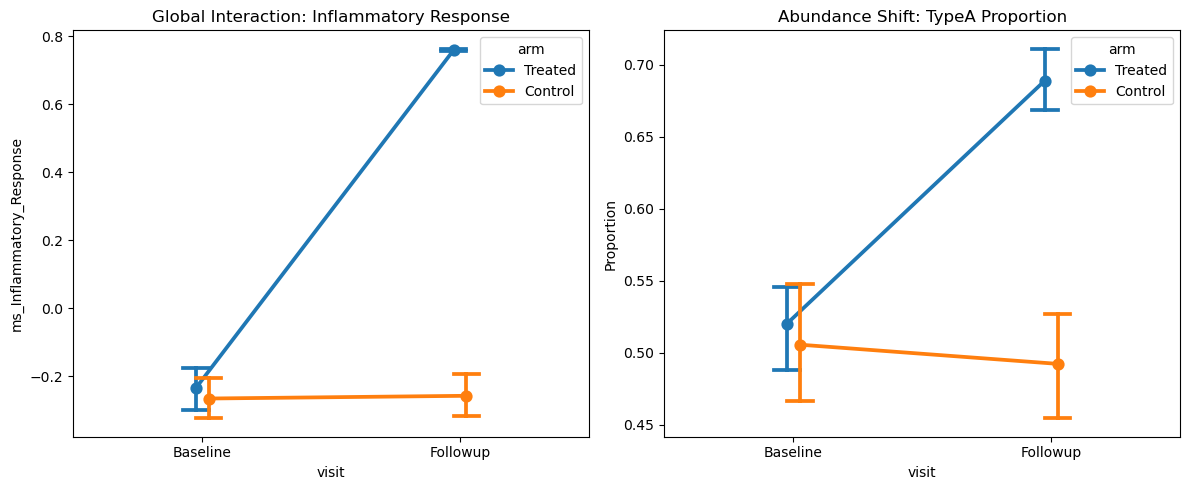

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

st.plot_trial_interaction(adata, "ms_Inflammatory_Response", design, ax=axes[0])
axes[0].set_title("Global Interaction: Inflammatory Response")

st.plot_abundance_interaction(adata, "TypeA", design, ax=axes[1])
axes[1].set_title("Abundance Shift: TypeA Proportion")

plt.tight_layout()
plt.show()


### Forest Plots
Compare effect sizes across multiple features or cell types.


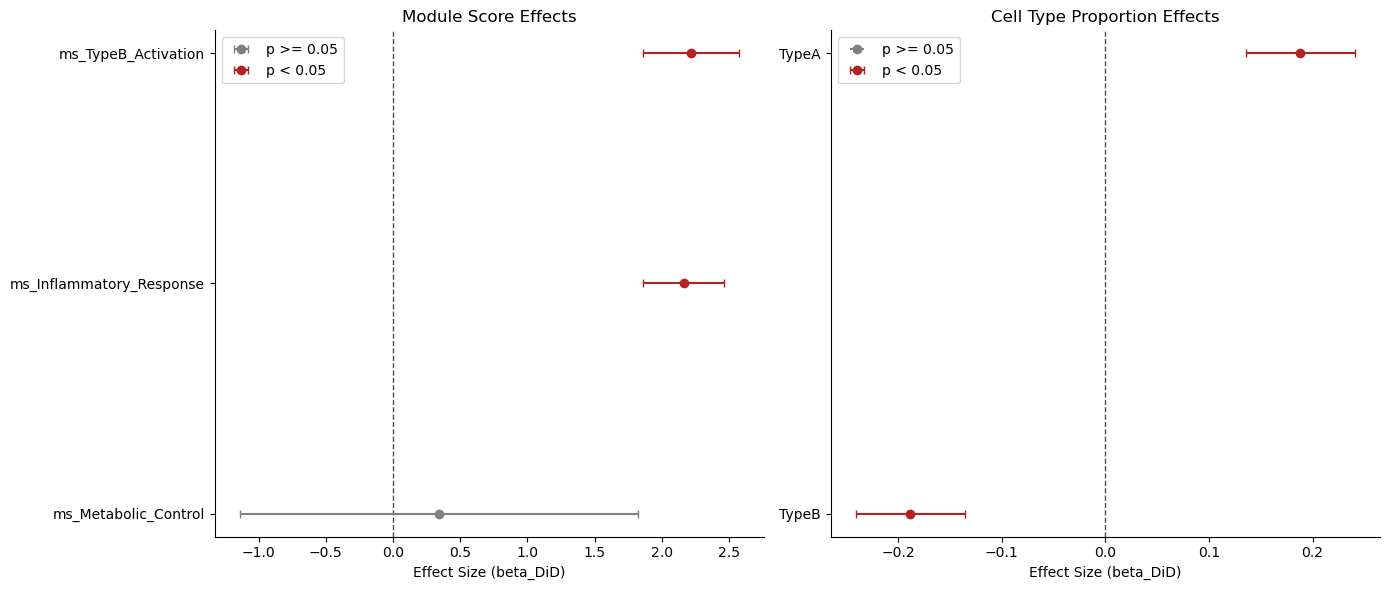

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

st.plot_did_forest(did_res, title="Module Score Effects", ax=axes[0])
st.plot_did_forest(ab_res, title="Cell Type Proportion Effects", feature_col="celltype", ax=axes[1])

plt.tight_layout()
plt.show()


### Within-Arm Longitudinal Analysis (Spaghetti Plots)
Visualize individual participant trajectories.


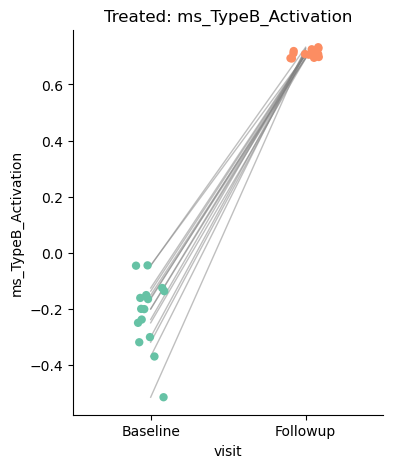

In [13]:
st.plot_within_arm_comparison(
    adata, 
    arm="Treated", 
    feature="ms_TypeB_Activation", 
    design=design, 
    visits=("Baseline", "Followup"),
    plot_type="paired"
)
plt.show()


### Trial-Aware UMAP Panel
Contextualize expression within the global cell-type landscape.


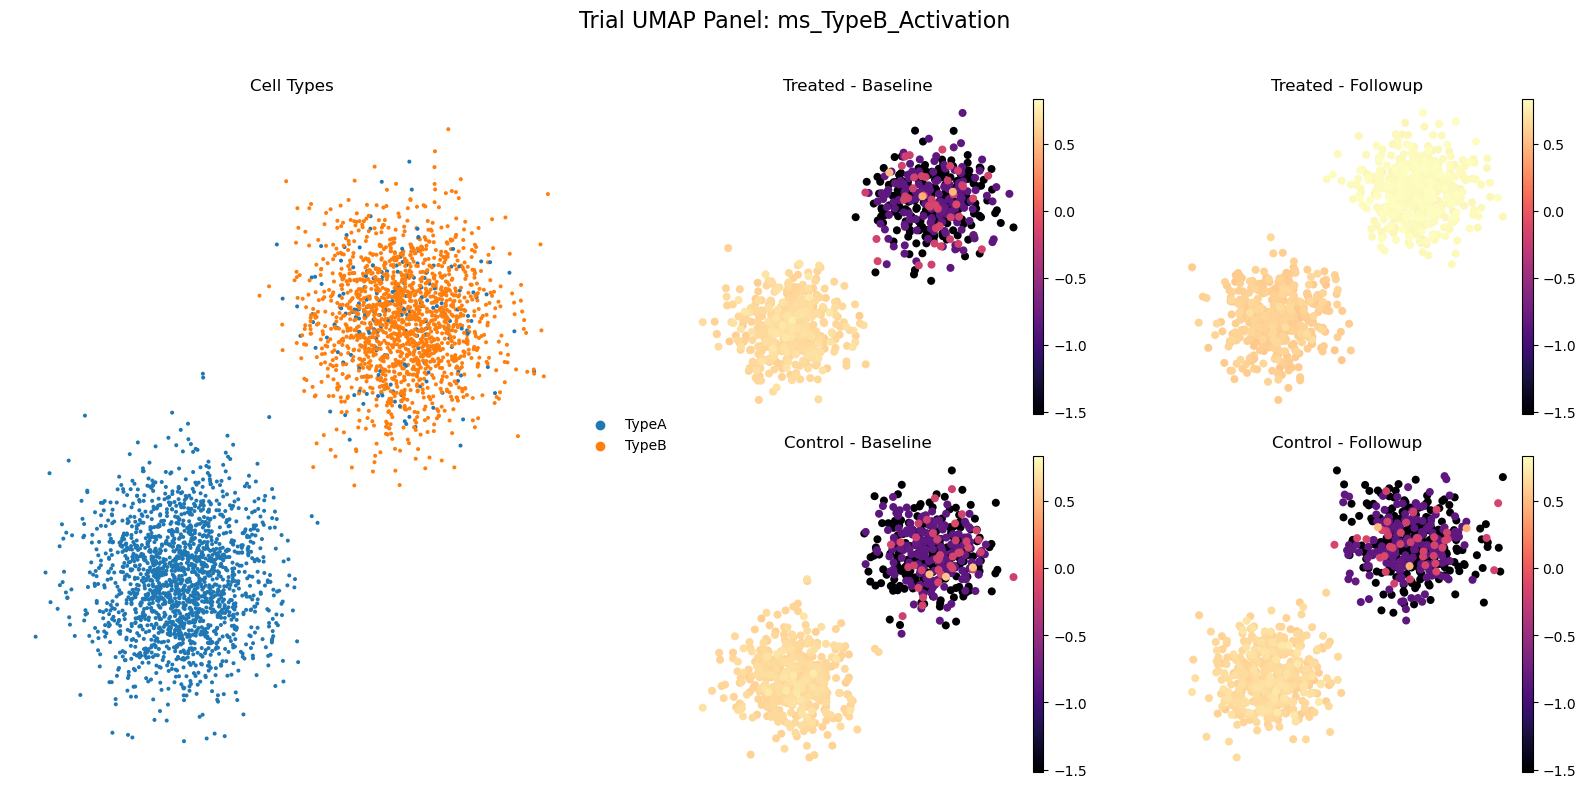

In [14]:
# We already have X_umap from make_blobs, which shows clear clusters.
st.plot_trial_umap_panel(adata, "ms_TypeB_Activation", design)
plt.show()


### GSEA Visualizations: Heatmap


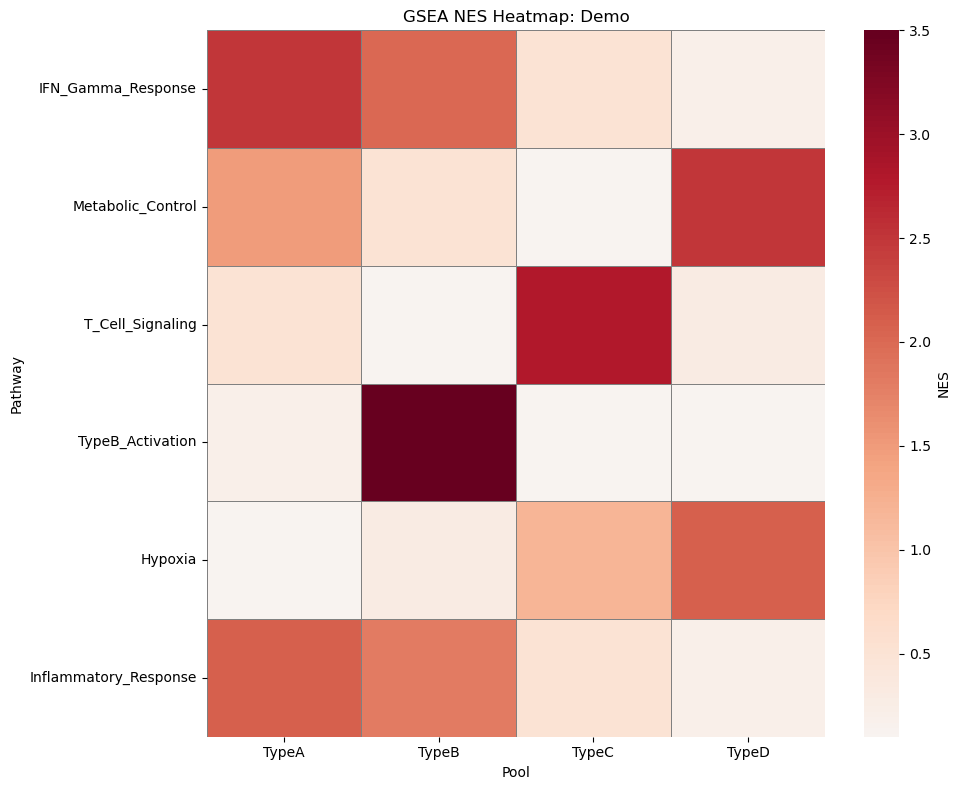

In [15]:
# Mocking multiple cell type GSEA results for demonstration
# We include more pathways and more cell types as requested
mock_gsea_all = pd.DataFrame({
    "Term": [
        "Inflammatory_Response", "TypeB_Activation", "Metabolic_Control", 
        "T_Cell_Signaling", "IFN_Gamma_Response", "Hypoxia"
    ] * 4,
    "pool": ["TypeA"] * 6 + ["TypeB"] * 6 + ["TypeC"] * 6 + ["TypeD"] * 6,
    "NES": [
        2.1, 0.2, 1.5, 0.5, 2.5, 0.1,  # TypeA
        1.8, 3.5, 0.5, 0.1, 2.0, 0.3,  # TypeB
        0.5, 0.1, 0.1, 2.8, 0.5, 1.2,  # TypeC
        0.2, 0.1, 2.5, 0.3, 0.2, 2.1   # TypeD
    ],
    "FDR q-val": [
        0.01, 0.8, 0.05, 0.6, 0.001, 0.9,
        0.02, 0.001, 0.7, 0.9, 0.01, 0.8,
        0.7, 0.9, 0.9, 0.001, 0.7, 0.05,
        0.9, 0.9, 0.001, 0.8, 0.9, 0.01
    ],
    "collection": ["Demo"] * 24
})

st.plot_gsea_heatmap(mock_gsea_all, collection="Demo", fdr_thresh=0.1, figsize=(10, 8))
plt.show()


### Trial Dotplot
Condensed view of expression across arms and cell types.


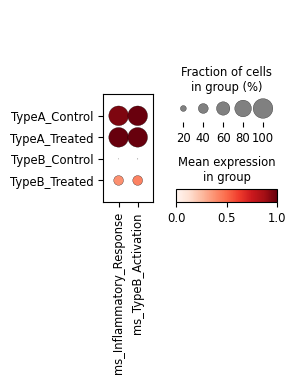

In [16]:
st.plot_trial_dotplot(
    adata, 
    features=["ms_Inflammatory_Response", "ms_TypeB_Activation"], 
    design=design,
    standard_scale="var"
)
plt.show()


## 9. Conclusion

The `sctrial` package provides a unified framework for:
1. **Controlling for heterogeneity** via participant fixed effects.
2. **Identifying specific responders** via Difference-in-Differences.
3. **Validating findings** through robust inference and stratified analysis.
4. **Communicating results** through high-impact, trial-aware visualizations.

Workflow completed successfully!
